In [26]:
import cv2
import numpy as np
import glob
import time
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline


logo_path = "logo_coca.png"
scene_paths = sorted(glob.glob("escenas/*.png"))  

Logo cargado con tamaño (alto, ancho): (4096, 4096)
Número de escenas cargadas: 5


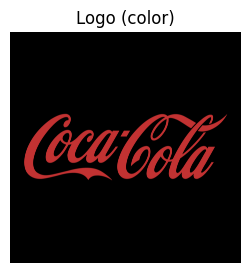

In [27]:
# Cargar logo
logo_color = cv2.imread(logo_path)
if logo_color is None:
    raise FileNotFoundError(f"No se pudo cargar el logo en: {logo_path}")

logo_gray = cv2.cvtColor(logo_color, cv2.COLOR_BGR2GRAY)

# Cargar escenas
scenes_color = []
scenes_gray = []

for p in scene_paths:
    img = cv2.imread(p)
    if img is None:
        print(f"[ADVERTENCIA] No se pudo cargar la imagen: {p}")
        continue
    scenes_color.append(img)
    scenes_gray.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))

print(f"Logo cargado con tamaño (alto, ancho): {logo_gray.shape}")
print(f"Número de escenas cargadas: {len(scenes_gray)}")

# Mostrar el logo
plt.figure(figsize=(3,3))
plt.imshow(cv2.cvtColor(logo_color, cv2.COLOR_BGR2RGB))
plt.title("Logo (color)")
plt.axis("off")
plt.show()



Procesando (Template Matching): Cocacola_Can.png


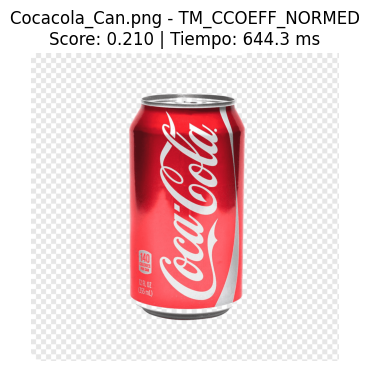

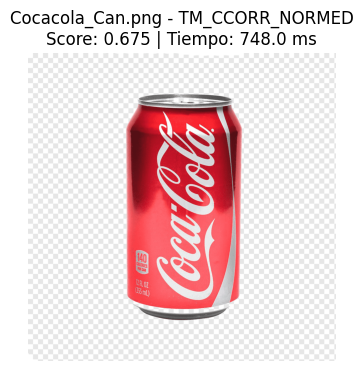

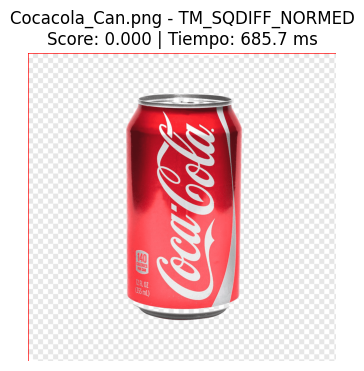


Procesando (Template Matching): Cocacola_bottle.png


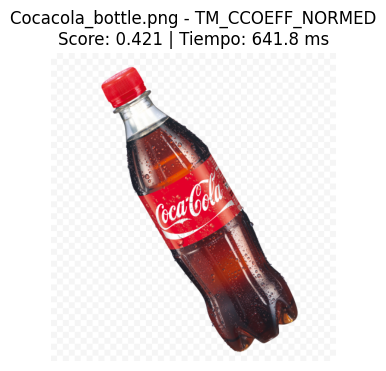

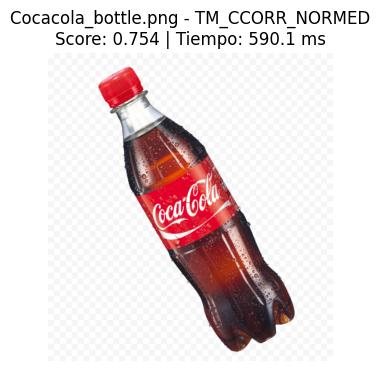

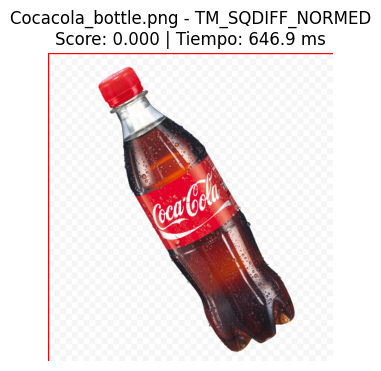


Procesando (Template Matching): cocacola_edificio.png


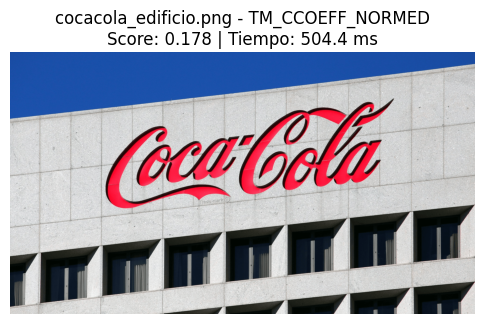

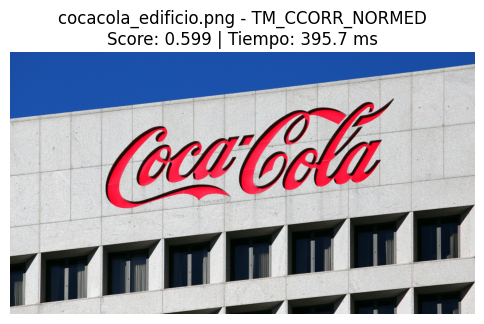

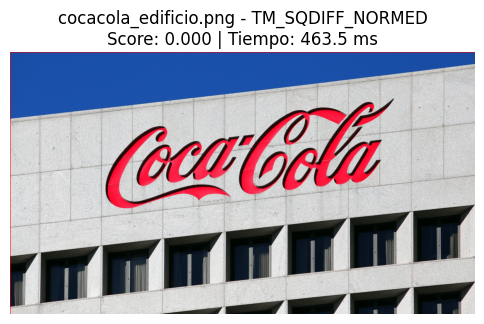


Procesando (Template Matching): cocacola_liter.png


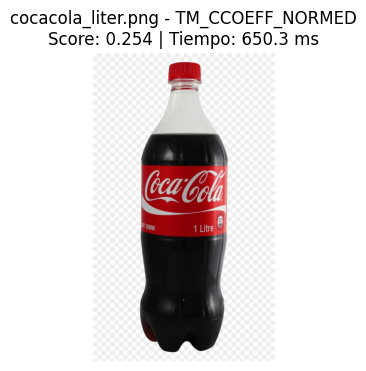

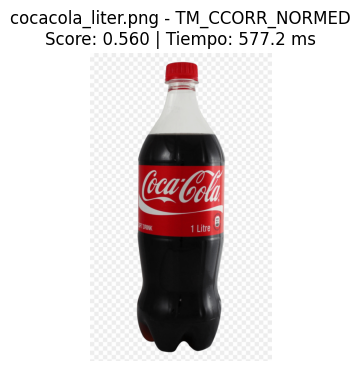

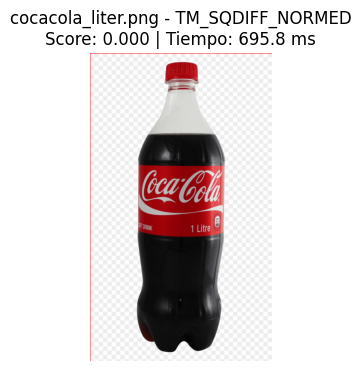


Procesando (Template Matching): cocacola_tapa.png


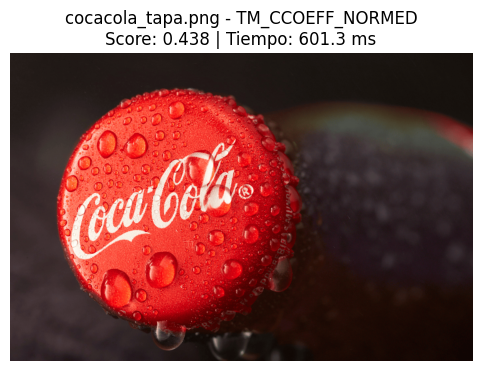

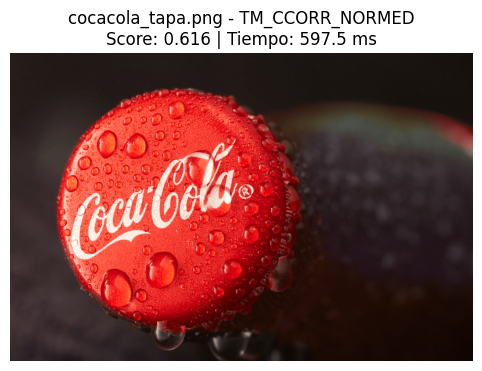

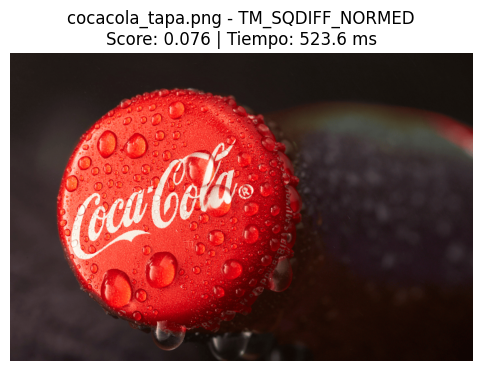


Template Matching terminado


In [30]:
# Métodos de template matching
methods = {
    "TM_CCOEFF_NORMED": cv2.TM_CCOEFF_NORMED,
    "TM_CCORR_NORMED": cv2.TM_CCORR_NORMED,
    "TM_SQDIFF_NORMED": cv2.TM_SQDIFF_NORMED,
}

h, w = logo_gray.shape[:2]

# Lista donde guardaremos los resultados
result_rows = []

umbral_template = 0.7  

for img_color, img_gray, path in zip(scenes_color, scenes_gray, scene_paths):
    img_name = os.path.basename(path)
    print(f"\nProcesando (Template Matching): {img_name}")

    for name, m in methods.items():
        t0 = time.time()
        res = cv2.matchTemplate(img_gray, logo_gray, m)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

        # Para métodos SQDIFF
        if m in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
            match_val = 1 - min_val
            top_left = min_loc
        else:
            match_val = max_val
            top_left = max_loc

        bottom_right = (top_left[0] + w, top_left[1] + h)
        img_draw = img_color.copy()
        cv2.rectangle(img_draw, top_left, bottom_right, (0, 0, 255), 2)

        elapsed_ms = (time.time() - t0) * 1000
        deteccion_auto = match_val >= umbral_template

        # Guardar fila en la tabla
        result_rows.append({
            "Imagen": img_name,
            "Metodo": f"Template-{name}",
            "Score_o_Matches": match_val,
            "Deteccion_correcta": None,         
            "Deteccion_auto_umbral": deteccion_auto,
            "Tiempo_ms": elapsed_ms
        })

        # Mostrar resultado 
        img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,4))
        plt.imshow(img_draw_rgb)
        plt.title(f"{img_name} - {name}\nScore: {match_val:.3f} | Tiempo: {elapsed_ms:.1f} ms")
        plt.axis("off")
        plt.show()

print("\nTemplate Matching terminado")



Procesando (ORB): Cocacola_Can.png


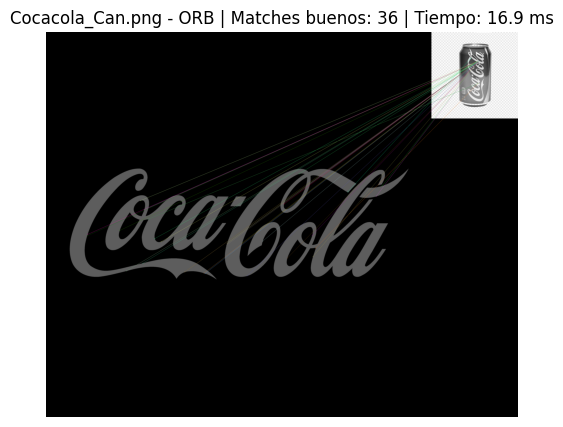


Procesando (ORB): Cocacola_bottle.png


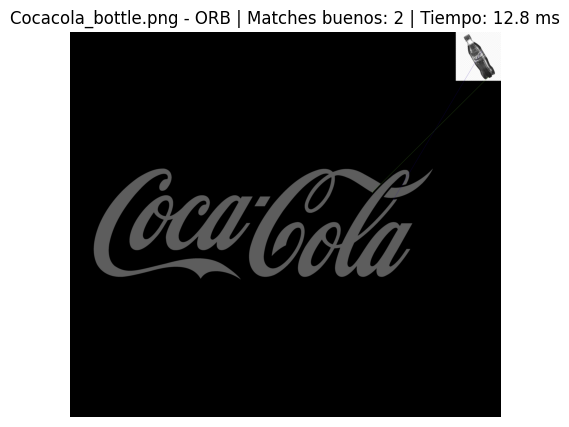


Procesando (ORB): cocacola_edificio.png


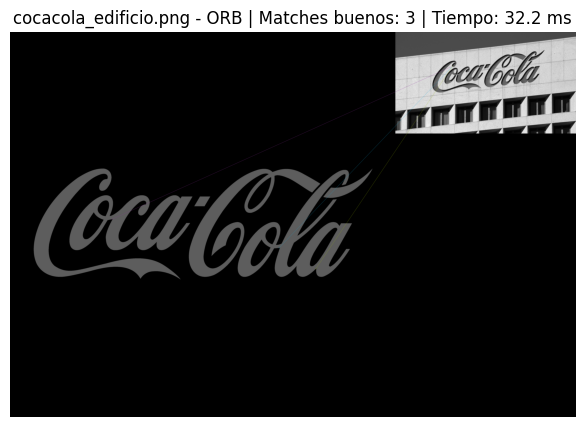


Procesando (ORB): cocacola_liter.png


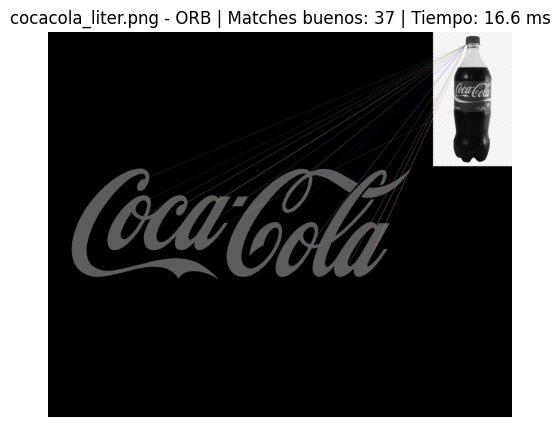


Procesando (ORB): cocacola_tapa.png


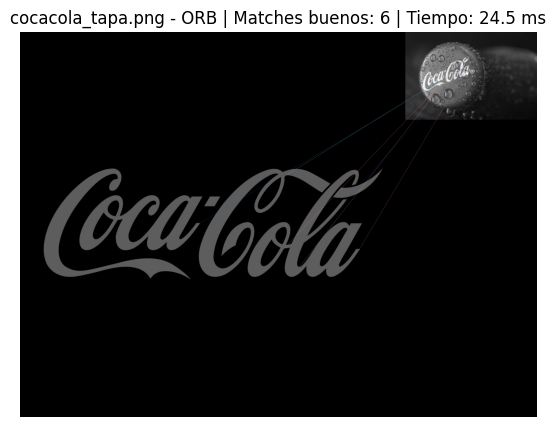


ORB terminado 


In [31]:
# ORB
orb = cv2.ORB_create(nfeatures=1000)

# Keypoints y descriptores del logo
kp_logo_orb, des_logo_orb = orb.detectAndCompute(logo_gray, None)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
umbral_matches_orb = 15  # mínimo de buenos matches 

for img_color, img_gray, path in zip(scenes_color, scenes_gray, scene_paths):
    img_name = os.path.basename(path)
    print(f"\nProcesando (ORB): {img_name}")

    t0 = time.time()
    kp_scene_orb, des_scene_orb = orb.detectAndCompute(img_gray, None)

    if des_scene_orb is None:
        good_orb = []
    else:
        matches = bf_orb.knnMatch(des_logo_orb, des_scene_orb, k=2)

        # Regla de Lowe 
        good_orb = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_orb.append(m)

    elapsed_ms = (time.time() - t0) * 1000
    deteccion_auto = len(good_orb) >= umbral_matches_orb

    # Dibujo de matches
    img_matches = cv2.drawMatches(
        logo_gray, kp_logo_orb,
        img_gray, kp_scene_orb,
        good_orb[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,5))
    plt.imshow(img_matches_rgb)
    plt.title(f"{img_name} - ORB | Matches buenos: {len(good_orb)} | Tiempo: {elapsed_ms:.1f} ms")
    plt.axis("off")
    plt.show()

    # Guardamos resultados numéricos
    result_rows.append({
        "Imagen": img_name,
        "Metodo": "ORB",
        "Score_o_Matches": len(good_orb),
        "Deteccion_correcta": None,          
        "Deteccion_auto_umbral": deteccion_auto,
        "Tiempo_ms": elapsed_ms
    })

print("\nORB terminado ")



Procesando (SIFT): Cocacola_Can.png


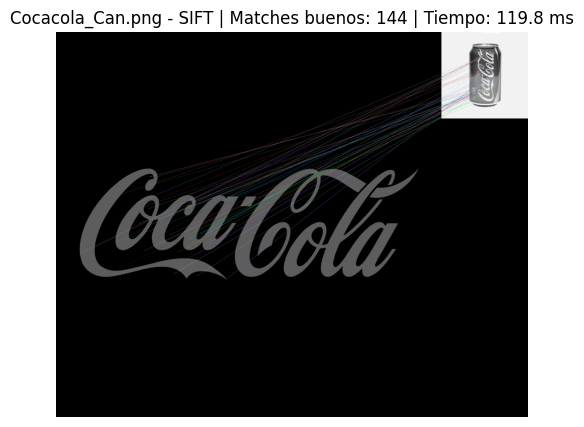


Procesando (SIFT): Cocacola_bottle.png


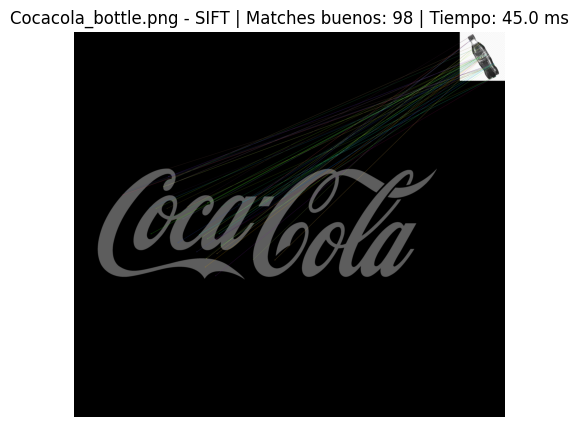


Procesando (SIFT): cocacola_edificio.png


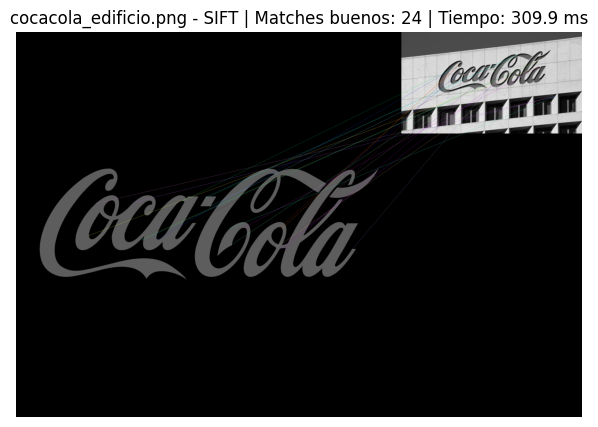


Procesando (SIFT): cocacola_liter.png


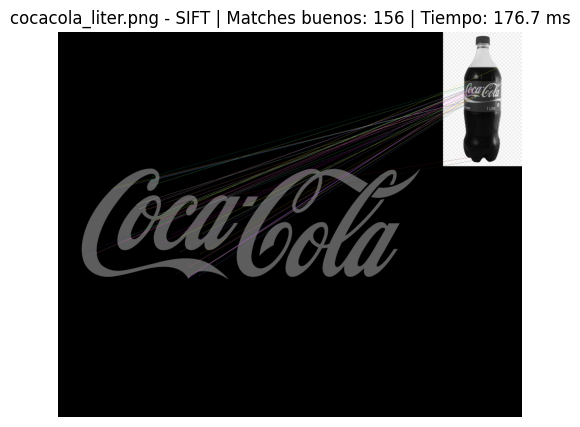


Procesando (SIFT): cocacola_tapa.png


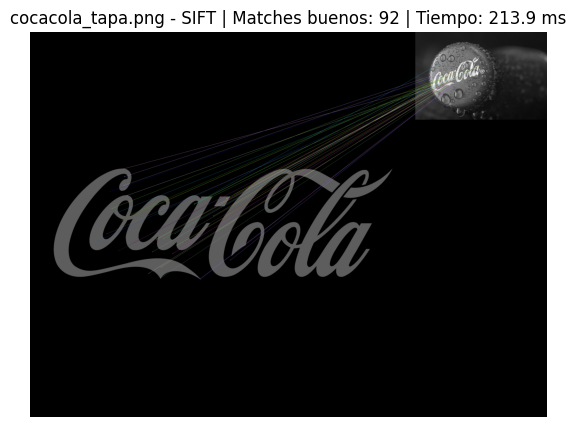


SIFT terminado 


In [32]:
# SIFT
sift = cv2.SIFT_create()
kp_logo_sift, des_logo_sift = sift.detectAndCompute(logo_gray, None)

bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
umbral_matches_sift = 10

for img_color, img_gray, path in zip(scenes_color, scenes_gray, scene_paths):
    img_name = os.path.basename(path)
    print(f"\nProcesando (SIFT): {img_name}")

    t0 = time.time()
    kp_scene_sift, des_scene_sift = sift.detectAndCompute(img_gray, None)

    if des_scene_sift is None:
        good_sift = []
    else:
        matches = bf_sift.knnMatch(des_logo_sift, des_scene_sift, k=2)

        good_sift = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_sift.append(m)

    elapsed_ms = (time.time() - t0) * 1000
    deteccion_auto = len(good_sift) >= umbral_matches_sift

    img_matches = cv2.drawMatches(
        logo_gray, kp_logo_sift,
        img_gray, kp_scene_sift,
        good_sift[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,5))
    plt.imshow(img_matches_rgb)
    plt.title(f"{img_name} - SIFT | Matches buenos: {len(good_sift)} | Tiempo: {elapsed_ms:.1f} ms")
    plt.axis("off")
    plt.show()

    result_rows.append({
        "Imagen": img_name,
        "Metodo": "SIFT",
        "Score_o_Matches": len(good_sift),
        "Deteccion_correcta": None,          
        "Deteccion_auto_umbral": deteccion_auto,
        "Tiempo_ms": elapsed_ms
    })

print("\nSIFT terminado ")


In [25]:
df = pd.DataFrame(result_rows)
df


,Imagen,Metodo,Score_o_Matches,Deteccion_correcta,Deteccion_auto_umbral,Tiempo_ms
0,Cocacola_Can.png,Template-TM_CCOEFF_NORMED,0.210398,None,False,670.219898
1,Cocacola_Can.png,Template-TM_CCORR_NORMED,0.675497,None,False,735.759020
2,Cocacola_Can.png,Template-TM_SQDIFF_NORMED,0.000000,None,False,675.798178
3,Cocacola_bottle.png,Template-TM_CCOEFF_NORMED,0.420724,None,False,633.089781
4,Cocacola_bottle.png,Template-TM_CCORR_NORMED,0.753986,None,True,543.865442
5,Cocacola_bottle.png,Template-TM_SQDIFF_NORMED,0.000000,None,False,644.142151
6,cocacola_edificio.png,Template-TM_CCOEFF_NORMED,0.178315,None,False,515.621662
7,cocacola_edificio.png,Template-TM_CCORR_NORMED,0.598655,None,False,424.730062
8,cocacola_edificio.png,Template-TM_SQDIFF_NORMED,0.000000,None,False,497.202635
9,cocacola_liter.png,Template-TM_CCOEFF_NORMED,0.254366,None,False,579.356909
